# Notebook 3 — Contesto stradale + stili di guida (e confronto powertrain)

**Ruolo nel progetto:** e' il pilastro **"riconoscimento del contesto di guida"**. Segmenta la
mappa di Ann Arbor in **cluster di tipologie di tratto** (urbano lento, rettilineo veloce,
incrocio congestionato...) dal comportamento aggregato dei veicoli che li percorrono - in modo
data-driven, senza etichette manuali.

**Perche' serve:** un assistente di guida non deve solo stimare il consumo (NB2): deve anche
*riconoscere che tipo di tratto* sta affrontando per applicare la strategia giusta. Il clustering
fornisce queste categorie.

**Tecniche del corso usate:**
- Standardizzazione (StandardScaler, con motivazione esplicita)
- PCA con interpretazione delle componenti
- K-Means con K-Means++ e n_init alto
- Elbow method + silhouette score per la scelta di $k$
- Caratterizzazione dei cluster con feature medie
- (Bonus) t-SNE per visualizzazione alternativa
- Visualizzazione geografica con Folium

**Input:** `outputs/ved_enriched.parquet`

**Due parti:** **A)** clustering dei *tratti stradali* (tipologie di strada); **B)** clustering dei *guidatori* per **stile di guida** dalla cinematica, con confronto **stile × powertrain (ICE/HEV/PHEV)** e confronto energetico. La Parte B usa solo feature cinematiche, valide per tutti i powertrain.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

DATA = Path("./outputs/ved_enriched.parquet")
print(f"Carico {DATA}")
df = pd.read_parquet(DATA)
print(f"Shape: {df.shape}")

Carico outputs\ved_enriched.parquet
Shape: (17922869, 21)


## 2. Aggregazione spaziale — il segmento è l'unità del clustering

**L'unità del clustering NON è la singola riga**, ma il **segmento stradale**. Definiamo un segmento come una cella della griglia geografica (~50×50 m, ottenuta arrotondando lat/lon a 4 decimali).

Per ogni cella calcoliamo statistiche aggregate del comportamento dei veicoli che ci sono passati:
- velocità media e std
- accelerazione media e std (variabilità → traffico/incroci)
- MAF medio (consumo tipico)
- RPM medio
- pendenza
- numero di passaggi (per filtrare celle con dati scarsi)

In [2]:
# Bin spaziali da ~50m
df['lat_bin'] = df['Latitude_deg'].round(4)
df['lon_bin'] = df['Longitude_deg'].round(4)

agg = df.groupby(['lat_bin', 'lon_bin']).agg(
    n_passages=('MAF_g_per_sec', 'size'),
    speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
    speed_std=('Vehicle_Speed_km_per_h', 'std'),
    accel_mean=('accel_kmh_s', 'mean'),
    accel_std=('accel_kmh_s', 'std'),
    accel_abs_mean=('accel_kmh_s', lambda s: s.abs().mean()),  # entropia di accelerazione
    maf_mean=('MAF_g_per_sec', 'mean'),
    rpm_mean=('Engine_RPM_RPM', 'mean'),
    load_mean=('Absolute_Load_pct', 'mean'),
    slope_mean=('slope', 'mean'),
    elevation=('elevation_m', 'mean'),
).reset_index()

# Frazione di stop (speed=0)
stops = df.groupby(['lat_bin', 'lon_bin'])['Vehicle_Speed_km_per_h'].apply(
    lambda s: (s < 2).mean()).reset_index(name='stop_fraction')
agg = agg.merge(stops, on=['lat_bin', 'lon_bin'])

print(f"Celle totali: {len(agg):,}")
print(f"Range n_passages: [{agg['n_passages'].min()}, {agg['n_passages'].max()}]")
agg.head()

Celle totali: 281,494
Range n_passages: [1, 3956]


,lat_bin,lon_bin,n_passages,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,maf_mean,rpm_mean,load_mean,slope_mean,elevation,stop_fraction
0,42.220299,-83.797203,3,64.000000,2.000000,-2.888889,3.421068,2.888889,2.846667,1174.666626,14.509804,-0.017660,272.0,0.0
1,42.220299,-83.796204,4,63.500000,3.696846,2.424423,1.126853,2.424423,30.075001,1737.000000,65.882355,0.003965,275.0,0.0
2,42.220299,-83.767197,4,36.500000,1.290994,1.655844,2.263432,1.655844,7.810000,1160.000000,35.294117,-0.075000,258.0,0.0
3,42.220299,-83.760902,5,35.000000,1.870829,-3.363636,6.520787,3.363636,3.978000,1304.800049,12.549020,0.060000,294.0,0.0
4,42.220299,-83.760803,6,42.666668,1.366260,-0.694444,1.107633,0.694444,4.763333,1590.166626,15.882354,0.050000,294.0,0.0


### 2.1 Filtro: scarta celle con dati scarsi

Celle con pochi passaggi sono rumorose: una statistica fatta su 3 punti non è significativa. Imponiamo una soglia minima (es. 50 osservazioni).

Celle dopo filtro (n_passages >= 50): 77,325 (rimosse 204,169)


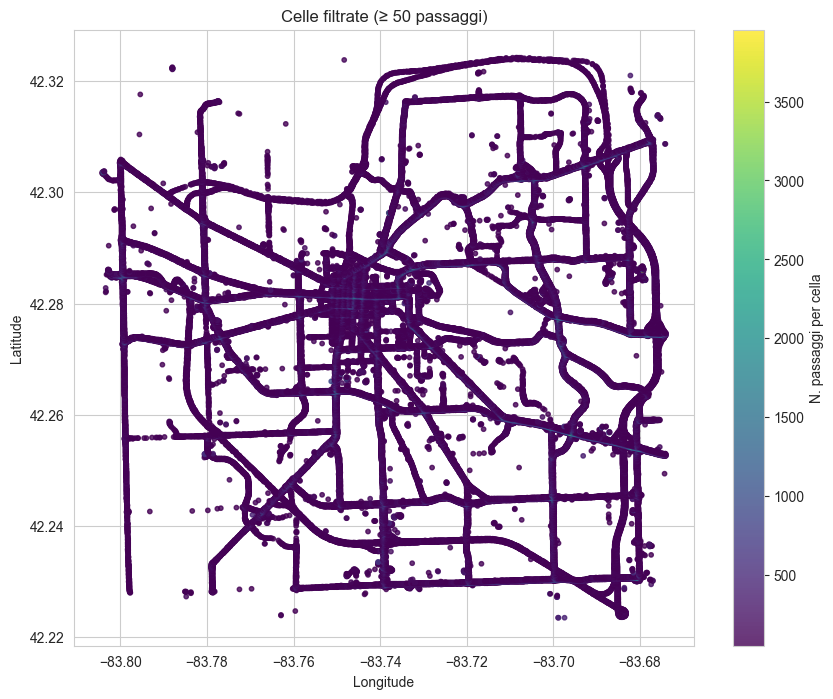

In [3]:
MIN_PASSAGES = 50
before = len(agg)
agg = agg[agg['n_passages'] >= MIN_PASSAGES].reset_index(drop=True)
print(f"Celle dopo filtro (n_passages >= {MIN_PASSAGES}): {len(agg):,} (rimosse {before-len(agg):,})")

# Visualizza la mappa dei dati rimanenti
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(agg['lon_bin'], agg['lat_bin'], c=agg['n_passages'],
                cmap='viridis', s=10, alpha=0.8)
plt.colorbar(sc, ax=ax, label='N. passaggi per cella')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Celle filtrate (≥ {MIN_PASSAGES} passaggi)')
plt.show()

## 3. Selezione delle feature per il clustering

Feature scelte: comportamento aggregato (velocità, accelerazione, MAF, RPM, load, fermate, pendenza). Escludiamo `n_passages` (è un meta-dato), `elevation` (assoluta, non utile per *tipo* di tratto), e le coordinate (non vogliamo che i cluster siano "vicinato A vs vicinato B", ma *tipologia* di guida).

In [4]:
FEATURES_CLUSTER = [
    'speed_mean', 'speed_std',
    'accel_mean', 'accel_std', 'accel_abs_mean',
    'maf_mean', 'rpm_mean', 'load_mean',
    'slope_mean', 'stop_fraction'
]

X = agg[FEATURES_CLUSTER].copy()
X = X.dropna()  # alcune celle potrebbero avere std NaN con un solo passaggio
agg_clean = agg.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)
print(f"Celle finali per clustering: {len(X):,}")
print(f"Feature: {len(FEATURES_CLUSTER)}")

X.describe()

Celle finali per clustering: 77,325
Feature: 10


,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,maf_mean,rpm_mean,load_mean,slope_mean,stop_fraction
count,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000
mean,46.282219,14.307227,-0.146671,3.614341,1.773129,10.290198,1245.449951,30.046078,0.000124,0.077770
std,23.008968,7.086949,0.903107,0.937117,0.670067,5.345526,369.859070,7.461113,0.018218,0.159084
min,0.000000,0.000000,-5.249651,0.000000,0.000000,0.074600,0.000000,0.000000,-0.082192,0.000000
25%,29.344944,8.913104,-0.632350,2.974992,1.295158,6.774464,1003.164612,25.147427,-0.006121,0.000000
50%,46.254467,13.176139,-0.132034,3.613687,1.688191,9.059175,1196.068237,29.473833,0.000000,0.000000
75%,58.077103,18.334269,0.346891,4.244734,2.176733,12.377143,1408.893677,34.283737,0.006000,0.084112
max,121.697365,57.487869,4.166846,7.239012,5.437530,75.102859,3651.800049,75.780396,0.081307,1.000000


## 4. Standardizzazione — perché è obbligatoria

Guarda le scale delle feature:
- `speed_mean`: 0–100 km/h
- `slope_mean`: -0.1 a 0.1
- `accel_std`: 0–5
- `rpm_mean`: 0–3000

Senza standardizzazione, K-Means calcolerebbe la distanza euclidea tra punti dominata da `rpm_mean` (range più ampio), e `slope_mean` sarebbe trascurata. Lo standardscaler riporta tutte le feature a media 0 e std 1.

In [5]:
# Esempio: cluster fatti SENZA standardizzazione (didattico)
demo_km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X)
print("Senza scaling, importanza relativa delle feature nella distanza euclidea:")
var_contrib = X.var() / X.var().sum()
print((var_contrib * 100).round(2).sort_values(ascending=False))
print("\n→ Le feature con range grande dominano TUTTO il clustering. Inaccettabile.\n")

# Ora con scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_CLUSTER)
print("Dopo standardizzazione:")
print(X_scaled_df.describe().loc[['mean', 'std']].round(3))

Senza scaling, importanza relativa delle feature nella distanza euclidea:
rpm_mean          99.52
speed_mean         0.39
speed_std          0.04
load_mean          0.04
maf_mean           0.02
accel_mean         0.00
accel_abs_mean     0.00
accel_std          0.00
slope_mean         0.00
stop_fraction      0.00
dtype: float64

→ Le feature con range grande dominano TUTTO il clustering. Inaccettabile.

Dopo standardizzazione:
      speed_mean  speed_std  accel_mean  accel_std  accel_abs_mean  maf_mean  \
mean         0.0        0.0        -0.0       -0.0            -0.0      -0.0   
std          1.0        1.0         1.0        1.0             1.0       1.0   

      rpm_mean  load_mean  slope_mean  stop_fraction  
mean       0.0        0.0         0.0            0.0  
std        1.0        1.0         1.0            1.0  


## 5. Scelta di K — Elbow Method + Silhouette

Proviamo K da 2 a 10. Per ogni K calcoliamo:
- **inerzia** (WCSS): somma dei quadrati delle distanze dai centroidi. Decresce sempre con K, ma il punto in cui rallenta è il "gomito".
- **silhouette score**: misura quanto i cluster sono ben separati. Va da -1 a 1, più alto è meglio.

  k=2: inertia=606345, silhouette=0.233
  k=3: inertia=514797, silhouette=0.194
  k=4: inertia=444648, silhouette=0.215
  k=5: inertia=388474, silhouette=0.232
  k=6: inertia=359630, silhouette=0.219
  k=7: inertia=338480, silhouette=0.177
  k=8: inertia=322075, silhouette=0.178
  k=9: inertia=306248, silhouette=0.180
  k=10: inertia=292371, silhouette=0.166


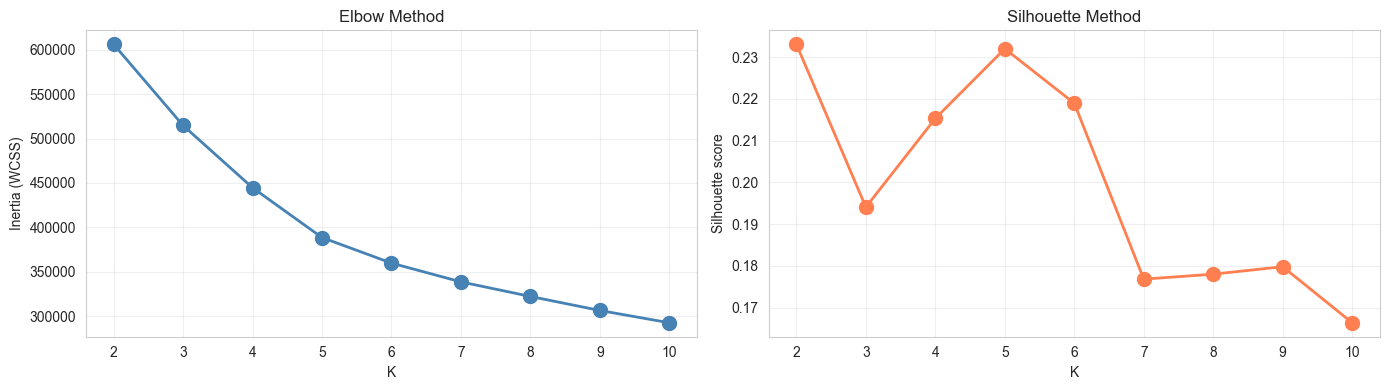

In [6]:
K_VALUES = list(range(2, 11))
inertias = []
silhouettes = []

# Silhouette è costosa: usiamo un sample per K alti
if len(X_scaled) > 10000:
    sil_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=10000, replace=False)
else:
    sil_idx = np.arange(len(X_scaled))

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=20, init='k-means++', random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled[sil_idx], labels[sil_idx])
    silhouettes.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_VALUES, inertias, 'o-', color='steelblue', lw=2, markersize=10)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_VALUES, silhouettes, 'o-', color='coral', lw=2, markersize=10)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Method')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1 Scelta finale di K

Combinando elbow (dove la pendenza dell'inerzia cambia bruscamente) e silhouette (massimo locale), tipicamente troveremo un buon valore tra **4 e 6**. Scegli il K che vedi essere il gomito; modifica `K_FINAL` se diverso.

In [7]:
# Default: prendiamo il K con miglior silhouette tra i "ragionevoli" (≥3, ≤7)
K_FINAL = K_VALUES[np.argmax([s if 3 <= k <= 7 else -1 for k, s in zip(K_VALUES, silhouettes)])]
print(f"K scelto: {K_FINAL}")
print("Puoi modificare K_FINAL manualmente se preferisci un altro valore basandoti sul gomito.")

K scelto: 5
Puoi modificare K_FINAL manualmente se preferisci un altro valore basandoti sul gomito.


## 6. K-Means finale

Eseguiamo il K-Means con K scelto, `n_init=50` per ridurre il rischio di minimo locale, e K-Means++ come strategia di inizializzazione (sceglie centroidi iniziali distanti tra loro).

In [8]:
kmeans = KMeans(n_clusters=K_FINAL, n_init=50, init='k-means++', random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)
agg_clean['cluster'] = labels

print("Distribuzione dei cluster:")
print(agg_clean['cluster'].value_counts().sort_index())

Distribuzione dei cluster:
cluster
0    13913
1    29880
2    19872
3     5812
4     7848
Name: count, dtype: int64


## 7. Caratterizzazione e naming dei cluster

**Questa è la sezione più importante del progetto.** Cluster senza interpretazione sono inutili. Per ogni cluster guardiamo le feature medie e gli diamo un nome interpretativo.

In [9]:
cluster_profile = agg_clean.groupby('cluster')[FEATURES_CLUSTER + ['n_passages']].mean().round(2)
cluster_profile['count'] = agg_clean['cluster'].value_counts().sort_index()
cluster_profile

,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,maf_mean,rpm_mean,load_mean,slope_mean,stop_fraction,n_passages,count
cluster,,,,,,,,,,,,
0,36.130001,15.730000,0.85,4.22,2.28,13.42,1397.880005,34.459999,0.0,0.08,256.40,13913
1,54.380001,10.930000,-0.11,3.03,1.36,9.09,1193.189941,29.820000,0.0,0.01,163.40,29880
2,33.810001,15.360000,-1.03,4.51,2.38,6.94,1008.609985,24.709999,0.0,0.08,220.90,19872
3,11.170000,13.240000,-0.12,2.96,1.14,6.05,920.630005,24.040001,-0.0,0.52,271.28,5812
4,91.040001,22.790001,0.16,2.99,1.37,20.92,2014.439941,41.029999,0.0,0.00,86.94,7848


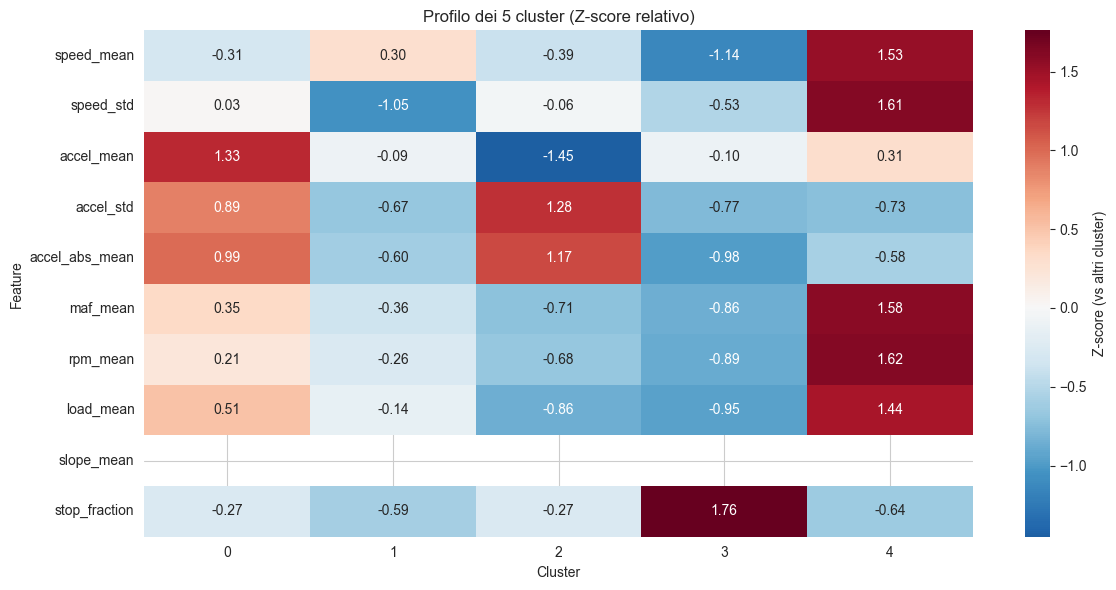

In [10]:
# Heatmap dei profili cluster (normalizzati su tutti i cluster per leggibilità)
profile_norm = (cluster_profile[FEATURES_CLUSTER] - cluster_profile[FEATURES_CLUSTER].mean()) / cluster_profile[FEATURES_CLUSTER].std()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(profile_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Z-score (vs altri cluster)'}, ax=ax)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
ax.set_title(f'Profilo dei {K_FINAL} cluster (Z-score relativo)')
plt.tight_layout()
plt.show()

### 7.1 Naming dei cluster

**ATTENZIONE: i cluster K-Means non hanno ordinamento fisso.** Ogni esecuzione produce cluster con gli stessi pattern ma numerati diversamente. Devi guardare la heatmap sopra e dare un nome a ciascun cluster manualmente.

**Pattern tipici che ci aspettiamo di trovare:**
- **Urbano lento / incrocio**: speed_mean basso, stop_fraction alto, accel_std alto, accel_abs_mean alto
- **Rettilineo veloce**: speed_mean alto, speed_std basso, accel_abs_mean basso, MAF medio
- **Salita sostenuta**: slope_mean positivo significativo, load_mean alto, MAF alto a parità di velocità
- **Discesa**: slope_mean negativo, load_mean basso
- **Tratto cittadino normale**: tutto vicino alla media

Esempio di naming (da adattare guardando la TUA heatmap):

In [11]:
# Naming automatico euristico basato sui profili (da rivedere manualmente!)
def auto_name(row):
    name = []
    if row['stop_fraction'] > cluster_profile['stop_fraction'].quantile(0.7):
        name.append('Urbano/Incrocio')
    elif row['speed_mean'] > cluster_profile['speed_mean'].quantile(0.7):
        name.append('Rettilineo veloce')
    elif row['slope_mean'] > 0.01:
        name.append('Tratto in salita')
    elif row['slope_mean'] < -0.01:
        name.append('Tratto in discesa')
    else:
        name.append('Cittadino misto')
    return ' | '.join(name) if name else 'Generico'

cluster_profile['name_auto'] = cluster_profile.apply(auto_name, axis=1)
cluster_names = cluster_profile['name_auto'].to_dict()
print("Naming proposto (verifica e modifica se necessario):")
for k, v in cluster_names.items():
    print(f"  Cluster {k}: {v}")

# Mappa nei dati
agg_clean['cluster_name'] = agg_clean['cluster'].map(cluster_names)

Naming proposto (verifica e modifica se necessario):
  Cluster 0: Cittadino misto
  Cluster 1: Rettilineo veloce
  Cluster 2: Cittadino misto
  Cluster 3: Urbano/Incrocio
  Cluster 4: Rettilineo veloce


## 8. PCA per visualizzazione e interpretazione

Riduciamo a 2 componenti per visualizzare i cluster nel piano. La PCA è anche utile per **interpretare** cosa lo spazio delle feature "premia": guardando i loadings vediamo quali feature contribuiscono di più alle prime componenti.

Varianza spiegata: PC1=36.4%, PC2=20.6%
Totale: 57.0%

Loadings:
                  PC1    PC2
speed_mean      0.410 -0.045
speed_std       0.119  0.236
accel_mean      0.268 -0.104
accel_std      -0.177  0.639
accel_abs_mean -0.144  0.646
maf_mean        0.472  0.160
rpm_mean        0.475  0.121
load_mean       0.442  0.085
slope_mean      0.006  0.001
stop_fraction  -0.223 -0.241


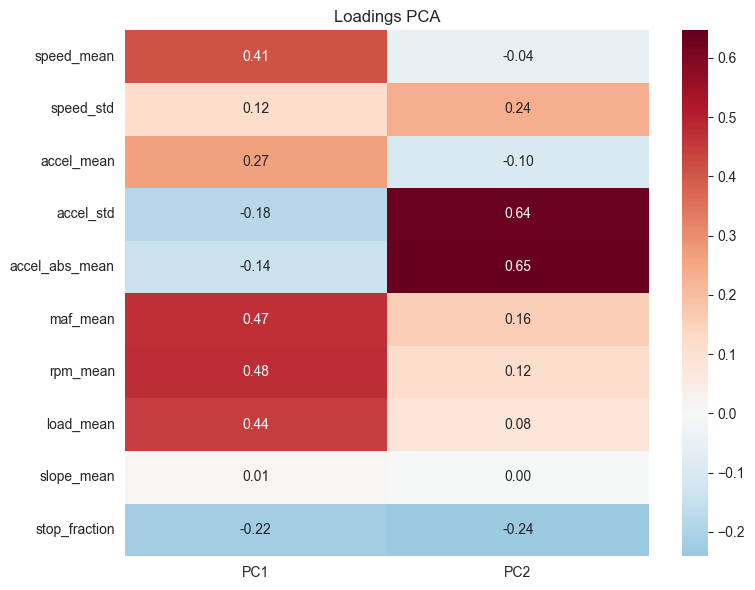

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza spiegata: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Totale: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Interpretazione: quali feature contribuiscono a ciascuna componente
loadings = pd.DataFrame(pca.components_.T, index=FEATURES_CLUSTER, columns=['PC1', 'PC2'])
print("\nLoadings:")
print(loadings.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Loadings PCA')
plt.tight_layout()
plt.show()

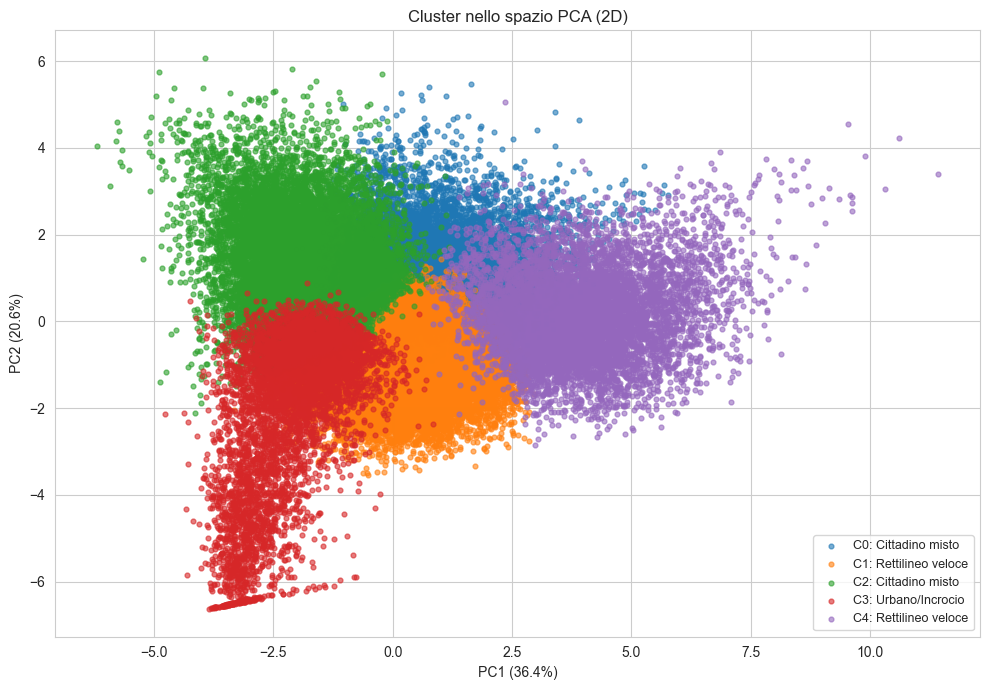

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', K_FINAL)
for c in sorted(agg_clean['cluster'].unique()):
    mask = agg_clean['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=12, alpha=0.6, color=palette[c],
               label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Cluster nello spazio PCA (2D)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Visualizzazione geografica — la mappa di Ann Arbor

**Questa è la sezione "deliverable visivo"** del progetto. Coloriamo la mappa di Ann Arbor con i cluster, ottenendo una vera classificazione geografica dei tipi di tratto stradale.

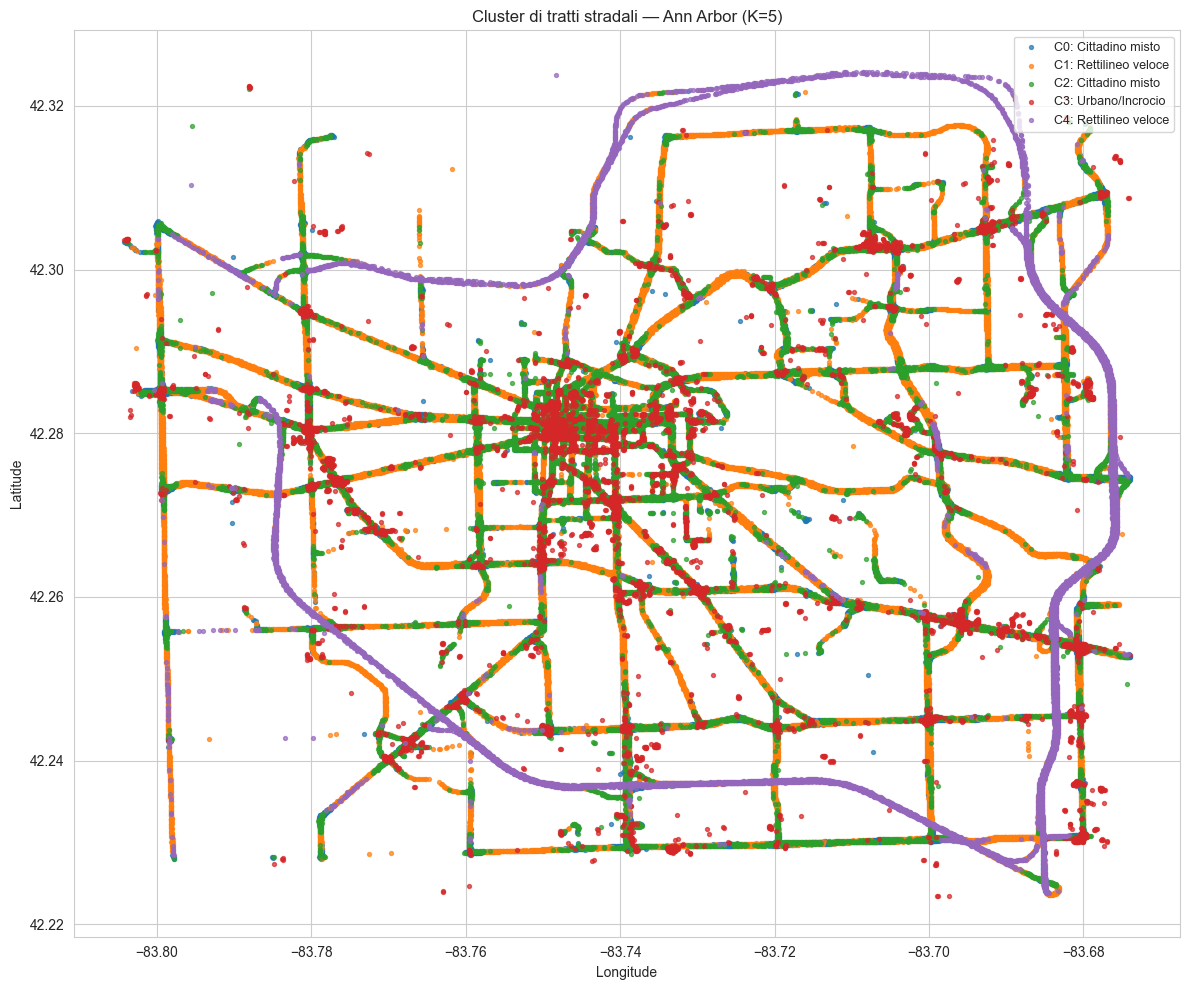

In [14]:
# Plot statico (matplotlib) — sempre disponibile
fig, ax = plt.subplots(figsize=(12, 10))
for c in sorted(agg_clean['cluster'].unique()):
    mask = agg_clean['cluster'] == c
    ax.scatter(agg_clean.loc[mask, 'lon_bin'], agg_clean.loc[mask, 'lat_bin'],
               s=8, alpha=0.7, color=palette[c],
               label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Cluster di tratti stradali — Ann Arbor (K={K_FINAL})')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('./outputs/cluster_map_static.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
# Mappa interattiva con folium (richiede: pip install folium)
try:
    import folium
    center = [agg_clean['lat_bin'].mean(), agg_clean['lon_bin'].mean()]
    m = folium.Map(location=center, zoom_start=13, tiles='cartodbpositron')
    
    # Palette hex per folium
    palette_hex = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'
                   for r, g, b in palette]
    
    # Subsample se troppi punti per Folium (massimo ~10k è ragionevole)
    plot_df = agg_clean.sample(n=min(10000, len(agg_clean)), random_state=RANDOM_STATE)
    
    for _, row in plot_df.iterrows():
        c = int(row['cluster'])
        folium.CircleMarker(
            location=[row['lat_bin'], row['lon_bin']],
            radius=3,
            color=palette_hex[c],
            fill=True,
            fill_opacity=0.7,
            popup=f"Cluster {c}: {cluster_names[c]}<br>"
                  f"Speed={row['speed_mean']:.1f} km/h<br>"
                  f"MAF={row['maf_mean']:.1f} g/s<br>"
                  f"Stop frac={row['stop_fraction']:.2f}"
        ).add_to(m)
    
    # Legenda HTML
    legend_html = '<div style="position: fixed; bottom: 30px; left: 30px; width: 250px; background: white; border:2px solid grey; padding: 10px; z-index: 1000;"><b>Cluster legend</b><br>'
    for c, name in cluster_names.items():
        legend_html += f'<i style="background:{palette_hex[c]}; width:12px; height:12px; display:inline-block;"></i> C{c}: {name}<br>'
    legend_html += '</div>'
    m.get_root().html.add_child(folium.Element(legend_html))
    
    OUT_MAP = Path('./outputs/cluster_map.html')
    m.save(str(OUT_MAP))
    print(f"✓ Mappa interattiva salvata: {OUT_MAP}")
    print("  Apri il file HTML nel browser per esplorarla.")
except ImportError:
    print("folium non installato. Installa con: pip install folium")
    print("Per ora va bene la mappa statica salvata sopra.")

✓ Mappa interattiva salvata: outputs\cluster_map.html
  Apri il file HTML nel browser per esplorarla.


## 10. (Bonus) t-SNE per visualizzazione non lineare

PCA è lineare e preserva struttura globale. t-SNE è non lineare e preserva struttura locale: spesso mostra cluster più "separati" visivamente.

**Limiti di t-SNE da ricordare:**
- Stocastico (risultati diversi a ogni run con random_state diverso)
- Lento su dataset grandi (campioniamo)
- Le distanze tra cluster nel plot finale **non sono interpretabili** in modo quantitativo

t-SNE su 5000 punti...


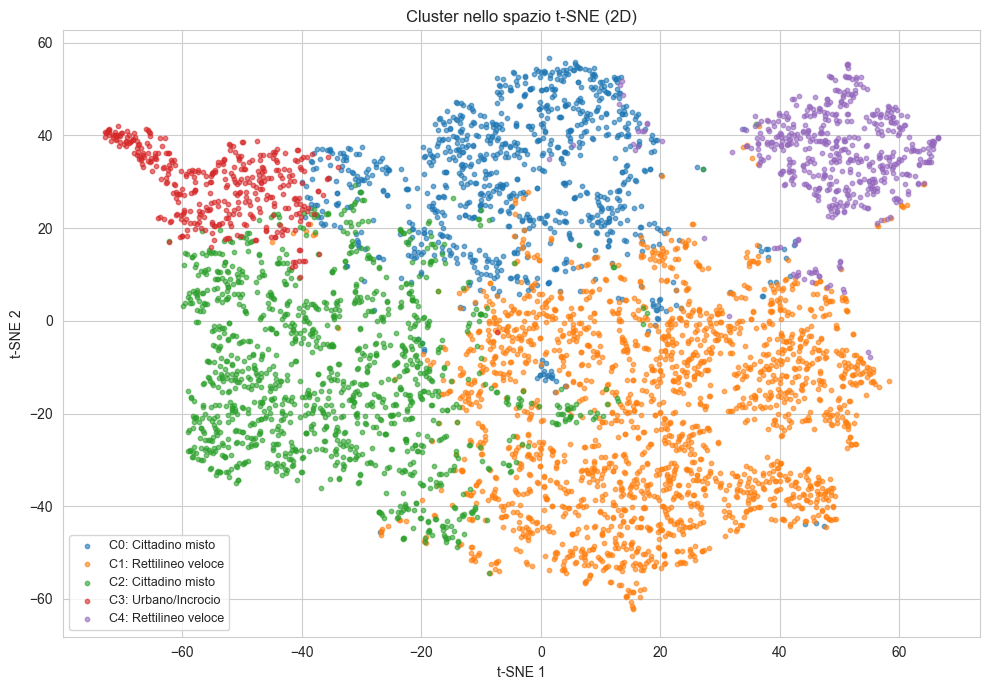

In [16]:
from sklearn.manifold import TSNE

n_tsne = min(5000, len(X_scaled))
idx_tsne = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=n_tsne, replace=False)

print(f"t-SNE su {n_tsne} punti...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            random_state=RANDOM_STATE, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled[idx_tsne])
labels_tsne = agg_clean['cluster'].iloc[idx_tsne].values

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(np.unique(labels_tsne)):
    mask = labels_tsne == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.6,
               color=palette[c], label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Cluster nello spazio t-SNE (2D)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Confronto cluster ↔ EngineType (sanity check)

Per ogni cluster di tratto stradale, qual è la composizione di EngineType dei veicoli che lo percorrono? In teoria dovrebbe essere abbastanza uniforme (i veicoli HEV percorrono le stesse strade degli ICE), ma se c'è una differenza è interessante.

Composizione EngineType per cluster (%):
EngineType                  HEV   ICE  PHEV
cluster cluster_name                       
0       Cittadino misto    29.8  59.0  11.3
1       Rettilineo veloce  32.2  51.4  16.4
2       Cittadino misto    29.4  57.2  13.3
3       Urbano/Incrocio    17.8  75.7   6.4
4       Rettilineo veloce  30.8  64.6   4.6


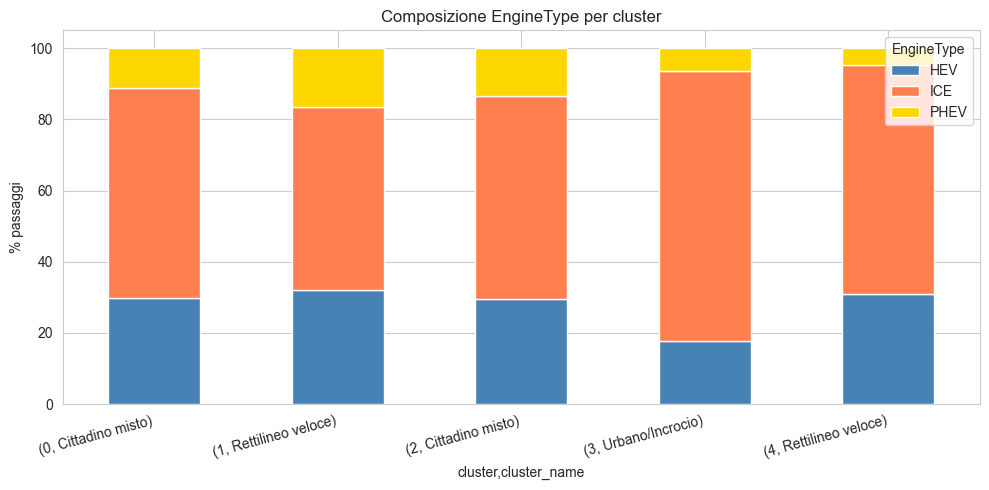

In [17]:
# Per ogni cella prendiamo la proporzione di passaggi per EngineType
engine_breakdown = df.merge(
    agg_clean[['lat_bin', 'lon_bin', 'cluster', 'cluster_name']],
    on=['lat_bin', 'lon_bin'], how='inner'
).groupby(['cluster', 'cluster_name', 'EngineType']).size().unstack(fill_value=0)
engine_breakdown_pct = engine_breakdown.div(engine_breakdown.sum(axis=1), axis=0) * 100

print("Composizione EngineType per cluster (%):")
print(engine_breakdown_pct.round(1))

engine_breakdown_pct.plot(kind='bar', stacked=True, figsize=(10, 5),
                          color=['steelblue', 'coral', 'gold'])
plt.ylabel('% passaggi')
plt.title('Composizione EngineType per cluster')
plt.xticks(rotation=15, ha='right')
plt.legend(title='EngineType', loc='upper right')
plt.tight_layout()
plt.show()

## 12. Salvataggio dei risultati

In [18]:
agg_clean.to_parquet('./outputs/road_segment_clusters.parquet', index=False)
cluster_profile.to_csv('./outputs/cluster_profile.csv')
print("✓ Salvati:")
print("  outputs/road_segment_clusters.parquet (segmenti con etichetta cluster)")
print("  outputs/cluster_profile.csv (profilo numerico dei cluster)")
print("  outputs/cluster_map_static.png (mappa)")
print("  outputs/cluster_map.html (mappa interattiva se folium installato)")

✓ Salvati:
  outputs/road_segment_clusters.parquet (segmenti con etichetta cluster)
  outputs/cluster_profile.csv (profilo numerico dei cluster)
  outputs/cluster_map_static.png (mappa)
  outputs/cluster_map.html (mappa interattiva se folium installato)


---
# Parte B — Stili di guida e confronto tra powertrain

Finora (Parte A) abbiamo clusterizzato i **tratti di strada**. Ora cambiamo unita': il **guidatore**
(`VehId`). Caratterizziamo lo **stile di guida** dalla sola **cinematica** (velocita', accelerazioni,
soste) — niente MAF/RPM. Questo e' fondamentale: la cinematica e' **valida e confrontabile per tutti
e tre i powertrain** (ICE/HEV/PHEV), mentre il consumo (MAF) no (per gli ibridi il motore si spegne).

Cosi' possiamo finalmente **confrontare i tre tipi di motore** in modo onesto: *i powertrain vengono
guidati in modo diverso?* E (solo per gli ICE, dove il MAF e' valido) *lo stile incide sul consumo?*

## B.1 Profilo cinematico per guidatore

Aggreghiamo la telemetria per `VehId`: velocita' media/variabilita'/crociera (p85), accelerazione
media e brusca, frenate brusche, frazione di sosta. Niente MAF/RPM -> feature powertrain-agnostiche.

In [19]:
g = df.groupby('VehId')
driver = g.agg(
    EngineType=('EngineType', 'first'),
    n=('VehId', 'size'),
    speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
    speed_std=('Vehicle_Speed_km_per_h', 'std'),
    speed_p85=('Vehicle_Speed_km_per_h', lambda s: s.quantile(0.85)),
    accel_abs_mean=('accel_kmh_s', lambda s: s.abs().mean()),
    accel_std=('accel_kmh_s', 'std'),
    frac_hard_accel=('accel_kmh_s', lambda s: (s > 6).mean()),
    frac_hard_decel=('accel_kmh_s', lambda s: (s < -6).mean()),
    stop_fraction=('Vehicle_Speed_km_per_h', lambda s: (s < 2).mean()),
).reset_index()

driver = driver[driver['n'] >= 2000].reset_index(drop=True)   # guidatori con dati sufficienti
STYLE_FEATURES = ['speed_mean','speed_std','speed_p85','accel_abs_mean','accel_std',
                  'frac_hard_accel','frac_hard_decel','stop_fraction']
print(f"Guidatori: {len(driver)} | per EngineType:")
print(driver['EngineType'].value_counts().to_string())
driver[STYLE_FEATURES].describe().round(3)

Guidatori: 278 | per EngineType:
EngineType
ICE     177
HEV      89
PHEV     12


,speed_mean,speed_std,speed_p85,accel_abs_mean,accel_std,frac_hard_accel,frac_hard_decel,stop_fraction
count,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000
mean,41.036,25.798,66.956,1.828,3.918,0.057,0.056,0.114
std,7.869,4.614,11.911,0.243,0.286,0.009,0.008,0.082
min,8.020,14.447,23.000,0.817,2.737,0.026,0.026,0.000
25%,35.747,22.415,60.250,1.698,3.762,0.052,0.051,0.037
50%,40.423,25.262,64.000,1.841,3.950,0.058,0.055,0.124
75%,45.642,28.474,69.060,2.006,4.118,0.063,0.061,0.160
max,69.748,42.003,118.000,2.403,4.663,0.081,0.084,0.667


## B.2 Standardizzazione e scelta di K (elbow + silhouette)

  k=2: inertia=1552, silhouette=0.287
  k=3: inertia=1218, silhouette=0.290
  k=4: inertia=1050, silhouette=0.228
  k=5: inertia=912, silhouette=0.246
  k=6: inertia=807, silhouette=0.250
  k=7: inertia=714, silhouette=0.256
  k=8: inertia=646, silhouette=0.262


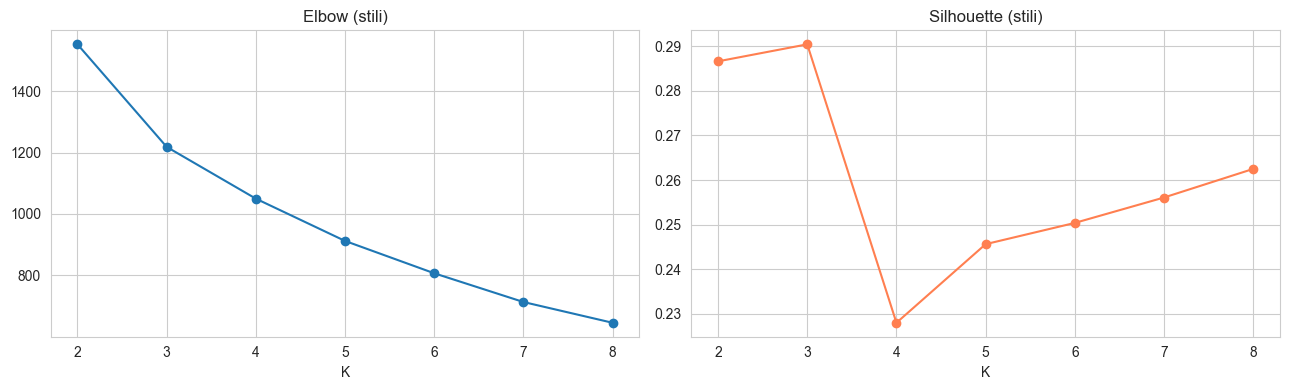

K scelto (stili): 3 (modifica a mano se preferisci il gomito)


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Xs = StandardScaler().fit_transform(driver[STYLE_FEATURES])
Ks = list(range(2, 9)); inertias=[]; sils=[]
for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, init='k-means++', random_state=RANDOM_STATE).fit(Xs)
    inertias.append(km.inertia_); sils.append(silhouette_score(Xs, km.labels_))
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sils[-1]:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Ks, inertias, 'o-'); axes[0].set_title('Elbow (stili)'); axes[0].set_xlabel('K')
axes[1].plot(Ks, sils, 'o-', color='coral'); axes[1].set_title('Silhouette (stili)'); axes[1].set_xlabel('K')
plt.tight_layout(); plt.show()
K_STYLE = Ks[int(np.argmax([s if 3 <= k <= 6 else -1 for k, s in zip(Ks, sils)]))]
print("K scelto (stili):", K_STYLE, "(modifica a mano se preferisci il gomito)")

## B.3 K-Means, profilo e naming degli stili

Naming euristico da rivedere guardando la heatmap (come per i cluster stradali).

       speed_mean  speed_std  speed_p85  accel_abs_mean  accel_std  frac_hard_accel  frac_hard_decel  stop_fraction    n
style                                                                                                                   
0       36.113998  24.745001  60.835999           1.591      3.658            0.049            0.049          0.159   91
1       40.201000  24.080999  63.639000           1.996      4.121            0.063            0.061          0.095  131
2       50.990002  31.524000  84.662003           1.820      3.865            0.056            0.054          0.085   56


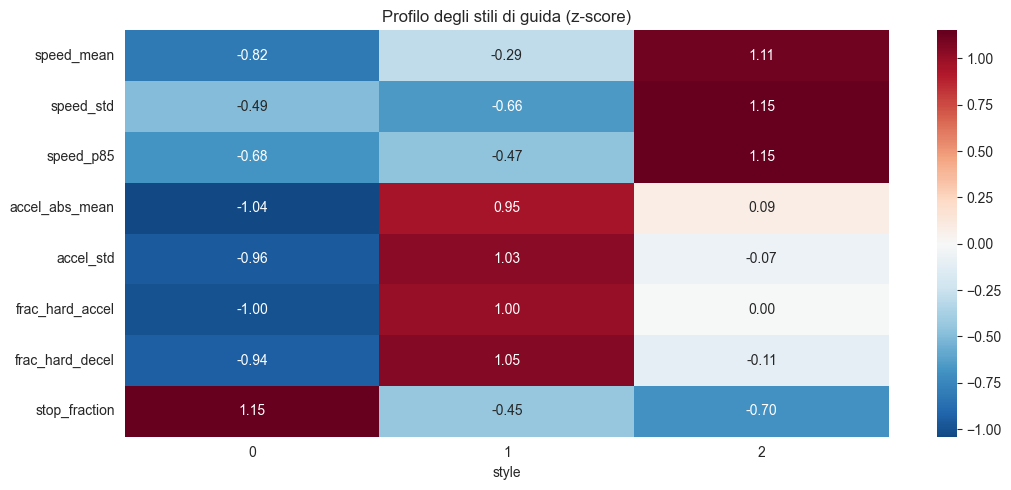


Naming proposto: {0: 'Urbano stop-and-go', 1: 'Aggressivo', 2: 'Crociera/extraurbano'}


In [21]:
km = KMeans(n_clusters=K_STYLE, n_init=50, init='k-means++', random_state=RANDOM_STATE)
driver['style'] = km.fit_predict(Xs)
prof = driver.groupby('style')[STYLE_FEATURES].mean().round(3)
prof['n'] = driver['style'].value_counts().sort_index()
print(prof.to_string())

prof_z = (prof[STYLE_FEATURES] - prof[STYLE_FEATURES].mean()) / prof[STYLE_FEATURES].std()
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(prof_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Profilo degli stili di guida (z-score)'); plt.tight_layout(); plt.show()

def name_style(r):
    if r['stop_fraction'] > prof['stop_fraction'].quantile(0.66): return 'Urbano stop-and-go'
    if r['frac_hard_accel'] + r['frac_hard_decel'] > (prof['frac_hard_accel']+prof['frac_hard_decel']).quantile(0.66): return 'Aggressivo'
    if r['speed_p85'] > prof['speed_p85'].quantile(0.66): return 'Crociera/extraurbano'
    return 'Moderato'
style_names = {i: name_style(prof.loc[i]) for i in prof.index}
driver['style_name'] = driver['style'].map(style_names)
print("\nNaming proposto:", style_names)

## B.4 PCA degli stili

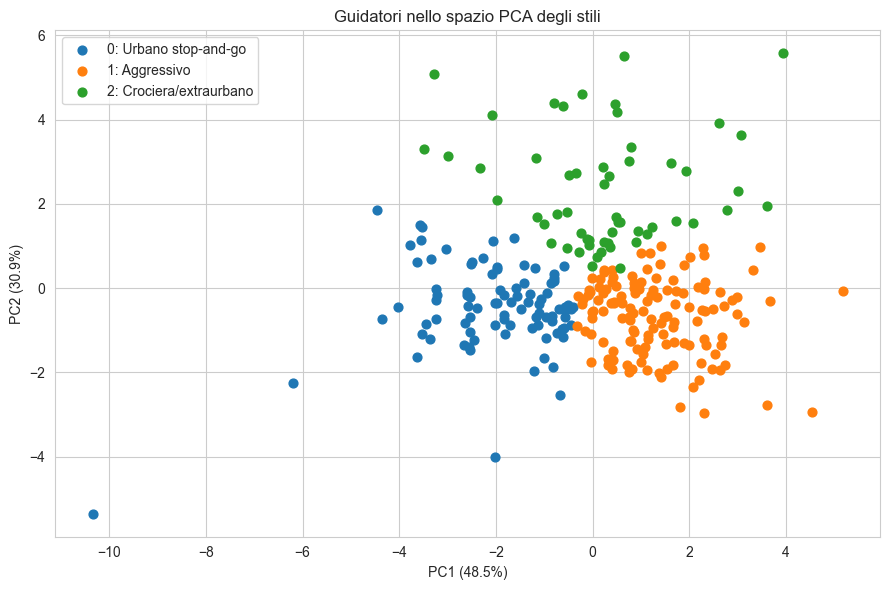

In [22]:
from sklearn.decomposition import PCA
pca_s = PCA(n_components=2, random_state=RANDOM_STATE)
Zs = pca_s.fit_transform(Xs)
fig, ax = plt.subplots(figsize=(9, 6))
pal = sns.color_palette('tab10', K_STYLE)
for c in sorted(driver['style'].unique()):
    m = driver['style'] == c
    ax.scatter(Zs[m, 0], Zs[m, 1], s=40, color=pal[c], label=f"{c}: {style_names[c]}")
ax.set_xlabel(f'PC1 ({pca_s.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_s.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Guidatori nello spazio PCA degli stili'); ax.legend(); plt.tight_layout(); plt.show()

## B.5 Stile di guida x tipo di motore (la domanda chiave)

I tre powertrain vengono guidati diversamente? Tabella di contingenza stile x EngineType + test
chi-quadro (le distribuzioni differiscono in modo statisticamente significativo?).

Conteggi (stile x EngineType):
EngineType            HEV  ICE  PHEV
style_name                          
Aggressivo             61   67     3
Crociera/extraurbano   19   34     3
Urbano stop-and-go      9   76     6

% per colonna (composizione di stile DENTRO ogni powertrain):
EngineType             HEV   ICE  PHEV
style_name                            
Aggressivo            68.5  37.9  25.0
Crociera/extraurbano  21.3  19.2  25.0
Urbano stop-and-go    10.1  42.9  50.0

Chi-quadro: chi2=34.05, dof=4, p=0.0000  -> differenze significative


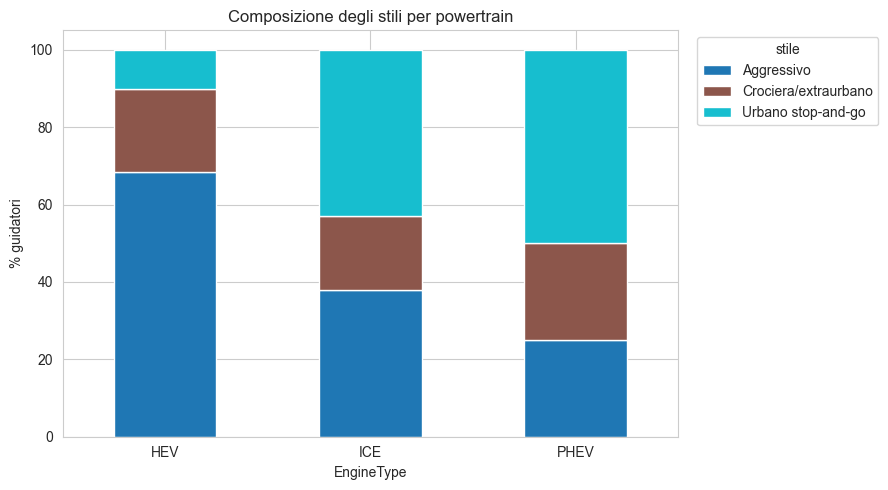

In [23]:
from scipy.stats import chi2_contingency
ct = pd.crosstab(driver['style_name'], driver['EngineType'])
ct_pct = pd.crosstab(driver['style_name'], driver['EngineType'], normalize='columns') * 100
print("Conteggi (stile x EngineType):"); print(ct.to_string())
print("\n% per colonna (composizione di stile DENTRO ogni powertrain):"); print(ct_pct.round(1).to_string())
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-quadro: chi2={chi2:.2f}, dof={dof}, p={p:.4f}  -> {'differenze significative' if p<0.05 else 'nessuna differenza significativa'}")
ct_pct.T.plot(kind='bar', stacked=True, figsize=(9,5), colormap='tab10')
plt.ylabel('% guidatori'); plt.title('Composizione degli stili per powertrain'); plt.xticks(rotation=0)
plt.legend(title='stile', bbox_to_anchor=(1.02,1)); plt.tight_layout(); plt.show()

## B.6 (Solo ICE) lo stile incide sul consumo?

Dove il MAF e' valido (ICE), calcoliamo il consumo per km di ogni guidatore e lo confrontiamo tra
gli stili. E' il payoff eco-driving: lo stile aggressivo/stop-and-go costa di piu'?

Consumo medio (g/km) per stile (solo ICE):
                        mean  median  count
style_name                                 
Aggressivo            1108.7  1074.2     67
Crociera/extraurbano  1044.9   993.3     34
Urbano stop-and-go    1193.0  1047.7     76


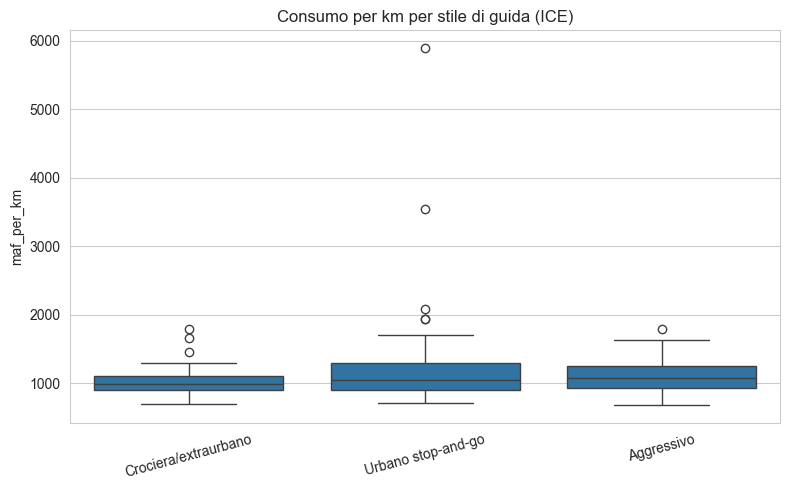

In [24]:
ice = df[df['EngineType'] == 'ICE'].copy()
ice['dt_s'] = (ice['dt_ms'].fillna(0)/1000).clip(0, 2)
cons = ice.groupby('VehId').apply(
    lambda d: (d['MAF_g_per_sec']*d['dt_s']).sum() / max(d['dist_m'].fillna(0).sum()/1000, 1e-6)
).rename('maf_per_km')
dcons = driver[driver['EngineType']=='ICE'].merge(cons, on='VehId', how='inner')
print("Consumo medio (g/km) per stile (solo ICE):")
print(dcons.groupby('style_name')['maf_per_km'].agg(['mean','median','count']).round(1).to_string())
fig, ax = plt.subplots(figsize=(8,5))
order = dcons.groupby('style_name')['maf_per_km'].median().sort_values().index
sns.boxplot(data=dcons, x='style_name', y='maf_per_km', order=order, ax=ax)
ax.set_title('Consumo per km per stile di guida (ICE)'); ax.set_xlabel(''); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## B.7 Confronto energetico tra powertrain (descrittivo)

Perche' gli ibridi non possono entrare nel modello di consumo: caratterizziamoli. (1) frazione di
**motore spento in marcia** (trazione elettrica); (2) **MAF in decelerazione** = firma della frenata
rigenerativa (gli ibridi vanno a ~0, l'ICE no).

            motore_spento_in_marcia_%  MAF_medio_in_decel
EngineType                                               
ICE                               0.0                5.86
HEV                              21.0                2.42
PHEV                             24.4                1.46


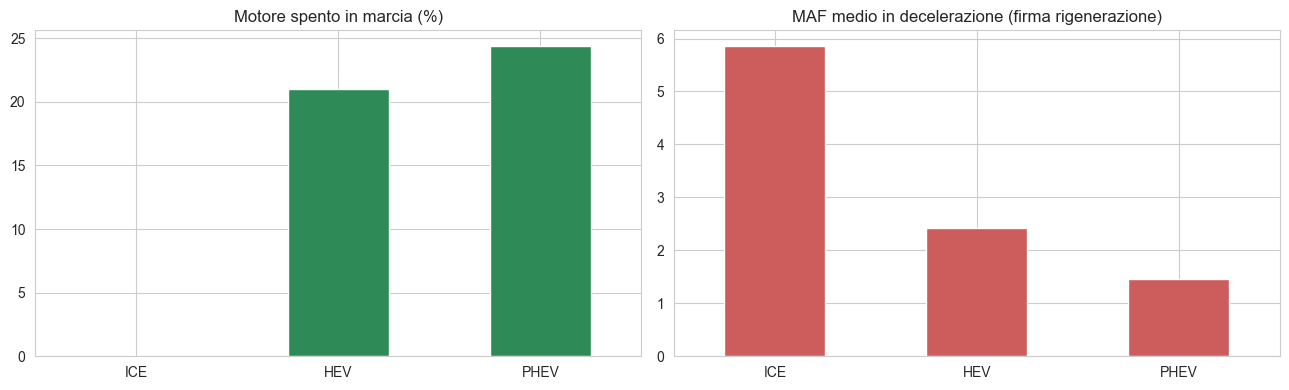


Lettura: ICE consuma aria anche in decel (motore sempre acceso); HEV/PHEV ~0 -> motore spento + frenata rigenerativa.


In [25]:
mov = df[df['Vehicle_Speed_km_per_h'] > 5]
eng_off = mov.assign(off=(mov['MAF_g_per_sec'] < 0.5)).groupby('EngineType')['off'].mean()*100
decel = df[(df['accel_kmh_s'] < -3) & (df['Vehicle_Speed_km_per_h'] > 5)]
maf_decel = decel.groupby('EngineType')['MAF_g_per_sec'].mean()
comp = pd.DataFrame({'motore_spento_in_marcia_%': eng_off.round(1), 'MAF_medio_in_decel': maf_decel.round(2)})
comp = comp.reindex(['ICE','HEV','PHEV'])
print(comp.to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comp['motore_spento_in_marcia_%'].plot(kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Motore spento in marcia (%)'); axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=0)
comp['MAF_medio_in_decel'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('MAF medio in decelerazione (firma rigenerazione)'); axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
print("\nLettura: ICE consuma aria anche in decel (motore sempre acceso); HEV/PHEV ~0 -> motore spento + frenata rigenerativa.")

---

## Riepilogo finale

**Cosa abbiamo costruito:**
- Aggregazione spaziale dei 17M punti in ~migliaia di celle (~50×50 m)
- Filtro qualità (≥ 50 passaggi per cella)
- Standardizzazione con motivazione esplicita (dimostrazione del fallimento senza scaling)
- Elbow + Silhouette per scelta di K
- K-Means con K-Means++ e n_init=50
- Caratterizzazione e naming dei cluster con heatmap z-score
- PCA con interpretazione dei loadings
- t-SNE come visualizzazione alternativa
- Mappa geografica statica + interattiva di Ann Arbor con cluster
- Confronto cluster ↔ EngineType

**Collegamento con il Notebook 2:** l'etichetta `cluster_name` potrebbe essere usata come feature aggiuntiva nel modello supervised (concettualmente: "il modello sa che il prossimo tratto sarà di tipo X"). Questo chiude il cerchio della narrativa del cruise control adattivo predittivo.

**Limitazioni (da menzionare nella presentazione):**
- K-Means assume cluster sferici e di dimensione simile; alternative come DBSCAN o HDBSCAN potrebbero trovare cluster di forma diversa
- L'aggregazione spaziale a celle quadrate è approssimativa: una segmentazione vera su grafo stradale (OpenStreetMap) sarebbe più accurata
- I cluster sono dipendenti dall'area: applicare a un'altra città richiederebbe ri-training

---
## Riepilogo (NB3 — contesto stradale + stili di guida)

**Parte A — contesto stradale:** clustering dei tratti (celle spaziali) in tipologie di strada;
StandardScaler motivato, elbow+silhouette, K-Means++, heatmap, PCA, t-SNE, mappa Folium.

**Parte B — stili di guida x powertrain:** clustering dei **guidatori** sulla sola **cinematica**
(valida per tutti i powertrain), confronto **stile x EngineType** (chi-quadro), e — solo per gli ICE
(dove il MAF e' valido) — relazione **stile -> consumo**. Piu' il **confronto energetico** tra i tre
motori (motore spento in marcia, firma della rigenerazione), che spiega perche' gli ibridi non
entrano nel modello di consumo (NB2).

**Tecniche del corso:** StandardScaler, K-Means/K-Means++, elbow, silhouette, PCA + loadings, t-SNE.